<a href="https://colab.research.google.com/github/NupoorRaut/Deep-Learning/blob/main/02_LearningRate_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Perform operation of OCR on alphabet dataset using the following :

Optimisers: 'Adam' , 'SGD', 'RmsProp'

Learning Rate: [0.001]

Batch Size: 24, 32


### first


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sachinpatel21/az-handwritten-alphabets-in-csv-format")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'az-handwritten-alphabets-in-csv-format' dataset.
Path to dataset files: /kaggle/input/az-handwritten-alphabets-in-csv-format


In [ ]:
import pandas as pd
df= pd.read_csv("/kaggle/input/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv")

In [ ]:
df

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372445,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372446,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372447,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372448,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(df.shape)

(372450, 785)


In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

print(X.shape)  # (372450, 784)
print(y.shape)  # (372450,)

(372450, 784)
(372450,)


In [ ]:
import numpy as np
unique, counts = np.unique(y, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique,
    "Count": counts
})

print(class_distribution)

    Class  Count
0       0  13869
1       1   8668
2       2  23409
3       3  10134
4       4  11440
5       5   1163
6       6   5762
7       7   7218
8       8   1120
9       9   8493
10     10   5603
11     11  11586
12     12  12336
13     13  19010
14     14  57825
15     15  19341
16     16   5812
17     17  11566
18     18  48419
19     19  22495
20     20  29008
21     21   4182
22     22  10784
23     23   6272
24     24  10859
25     25   6076


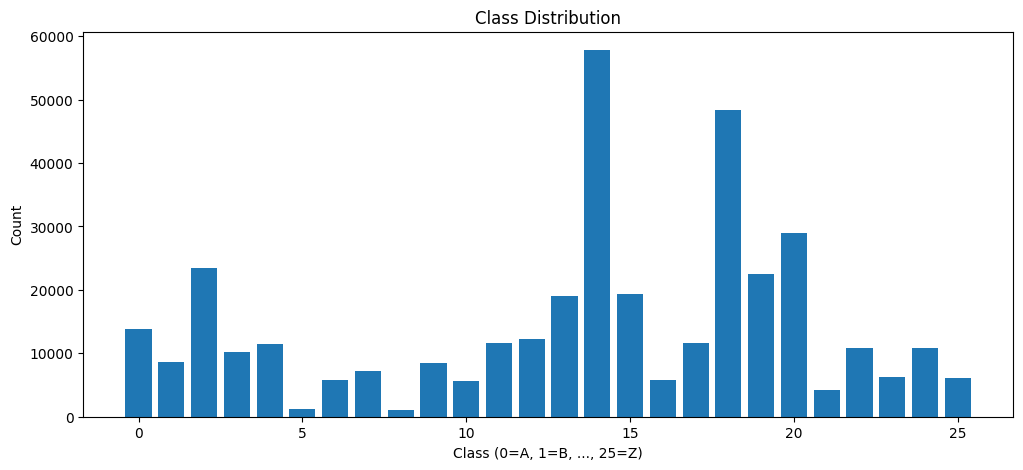

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.bar(unique, counts)
plt.title("Class Distribution")
plt.xlabel("Class (0=A, 1=B, ..., 25=Z)")
plt.ylabel("Count")
plt.show()

In [ ]:
import string

alphabet = list(string.ascii_uppercase)

class_distribution["Letter"] = class_distribution["Class"].apply(lambda x: alphabet[x])

print(class_distribution)

    Class  Count Letter
0       0  13869      A
1       1   8668      B
2       2  23409      C
3       3  10134      D
4       4  11440      E
5       5   1163      F
6       6   5762      G
7       7   7218      H
8       8   1120      I
9       9   8493      J
10     10   5603      K
11     11  11586      L
12     12  12336      M
13     13  19010      N
14     14  57825      O
15     15  19341      P
16     16   5812      Q
17     17  11566      R
18     18  48419      S
19     19  22495      T
20     20  29008      U
21     21   4182      V
22     22  10784      W
23     23   6272      X
24     24  10859      Y
25     25   6076      Z


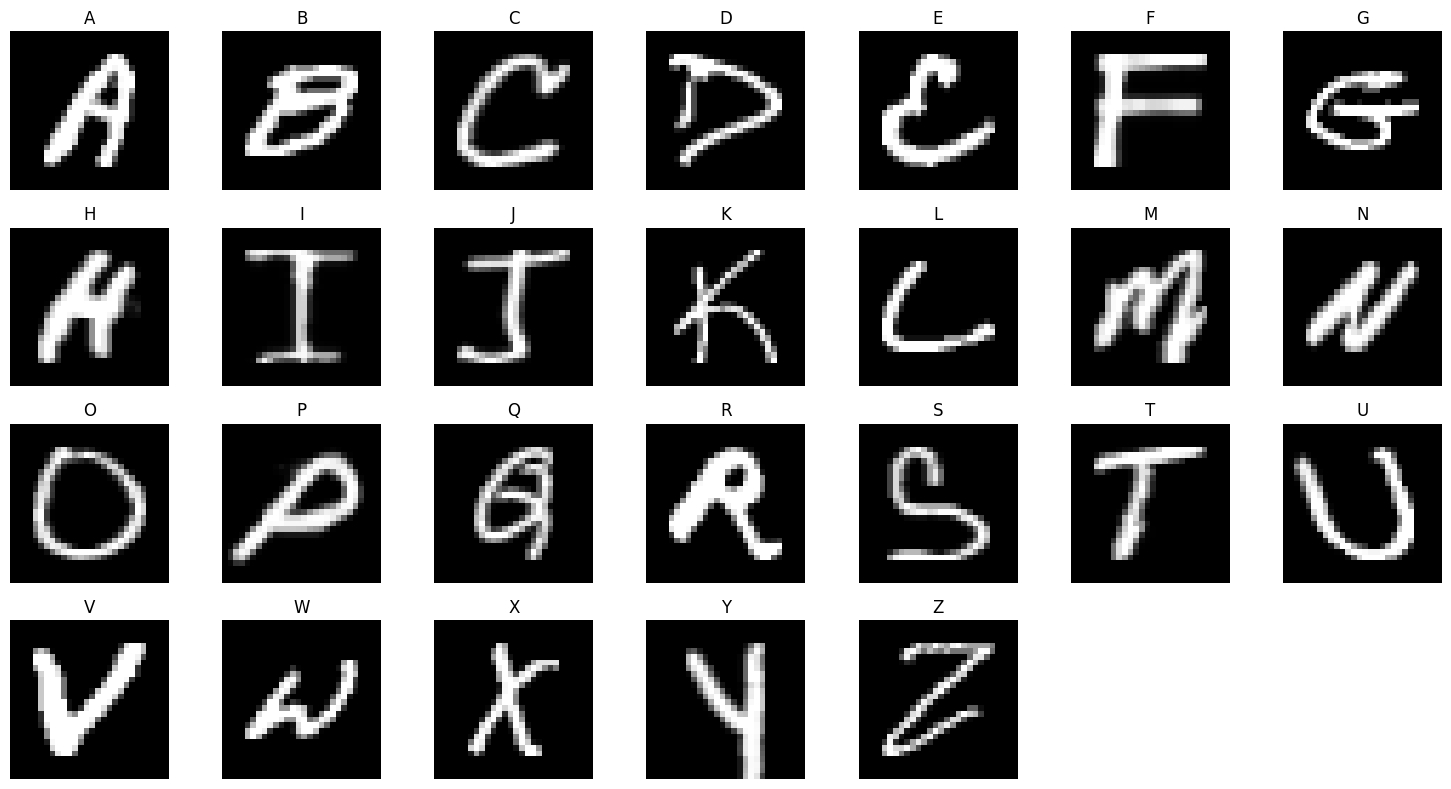

In [ ]:
plt.figure(figsize=(15,8))

for i in range(26):
    index = np.where(y == i)[0][0]
    img = X[index].reshape(28,28)

    plt.subplot(4,7,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(alphabet[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

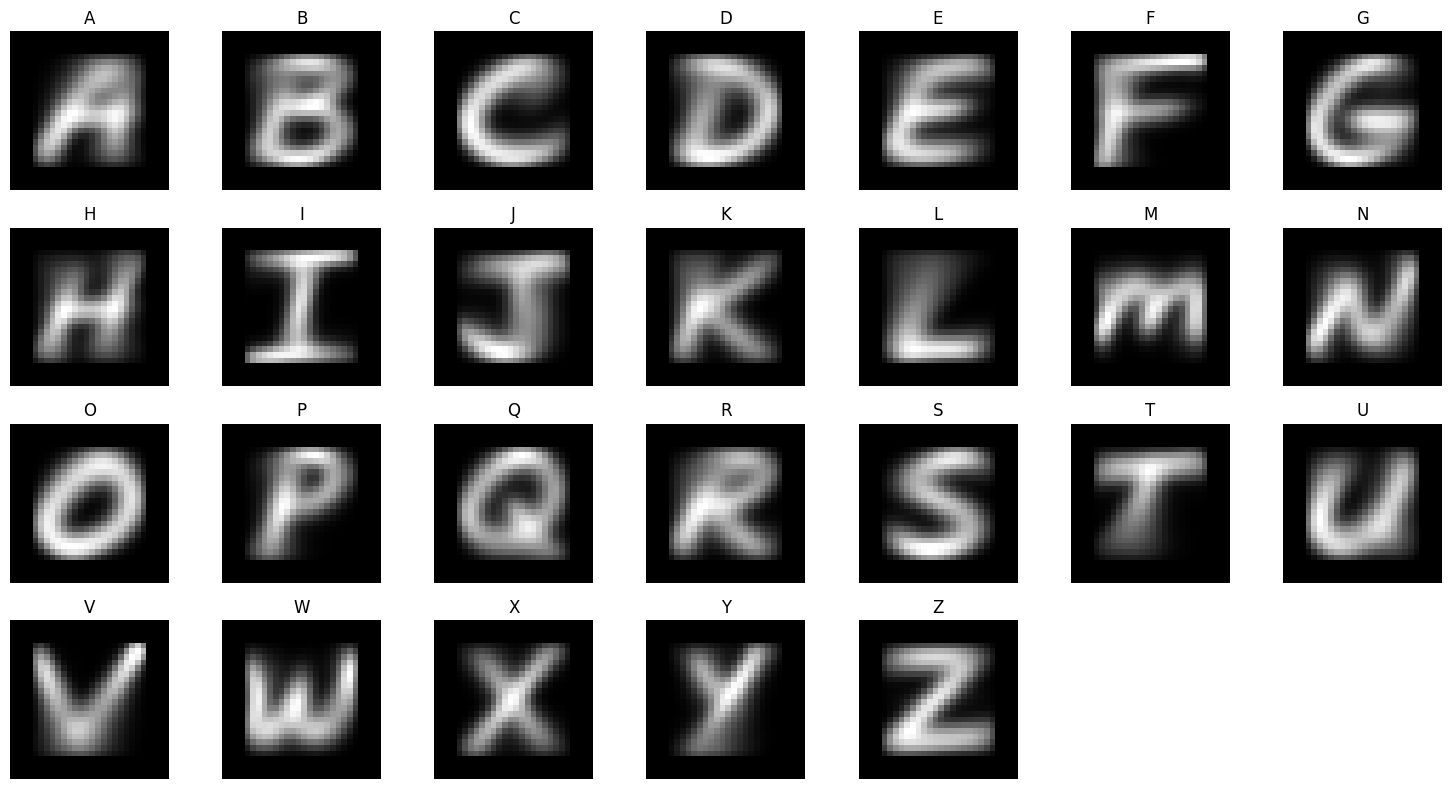

In [ ]:
plt.figure(figsize=(15,8))

for i in range(26):
    class_images = X[y == i]
    mean_image = np.mean(class_images, axis=0).reshape(28,28)

    plt.subplot(4,7,i+1)
    plt.imshow(mean_image, cmap='gray')
    plt.title(alphabet[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Dataset slightly imbalanced

Background pixels dominate

Some letters visually similar

High intra-class variation

Grayscale, not RGB

Centered but not perfectly aligned

##//Part 2


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sachinpatel21/az-handwritten-alphabets-in-csv-format")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'az-handwritten-alphabets-in-csv-format' dataset.
Path to dataset files: /kaggle/input/az-handwritten-alphabets-in-csv-format


In [ ]:
import pandas as pd
df= pd.read_csv("/kaggle/input/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data/A_Z Handwritten Data.csv")

In [ ]:
# Split features & labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0]


In [ ]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


In [ ]:
# Convert to float32
X = X.astype('float32')
y = y.values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Class names (A-Z)
class_names = [chr(i) for i in range(65, 91)]

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_metrics(y_true, y_pred, y_proba, history, class_names, title="Model"):

    plt.figure(figsize=(12,10))

    # ----------------------------
    # 1. Confusion Matrix (FIXED)
    # ----------------------------
    plt.subplot(2,2,1)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm,
                annot=True,              # ✅ numbers inside boxes
                fmt='d',                 # integer format
                cmap='Blues',
                xticklabels=class_names, # ✅ class labels
                yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    # ----------------------------
    # 2. ROC Curve
    # ----------------------------
    plt.subplot(2,2,2)

    y_bin = label_binarize(y_true, classes=range(len(class_names)))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(fontsize=7)

    # ----------------------------
    # 3. Accuracy Curve
    # ----------------------------
    plt.subplot(2,2,3)
    if history is not None:
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy vs Epoch")
        plt.legend()
    else:
        plt.text(0.3, 0.5, "No history available")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
num_classes = len(class_names)

def create_model(optimizer):
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
optimizer_classes = {
    "Adam": tf.keras.optimizers.Adam,
    "SGD": tf.keras.optimizers.SGD,
    "RMSprop": tf.keras.optimizers.RMSprop
}

batch_sizes = [24, 32]
results = []
histories = {}



Training with Adam | Batch Size: 24
Epoch 1/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.8916 - loss: 0.3750 - val_accuracy: 0.9558 - val_loss: 0.1547
Epoch 2/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9326 - loss: 0.2304 - val_accuracy: 0.9624 - val_loss: 0.1281
Epoch 3/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9406 - loss: 0.2014 - val_accuracy: 0.9663 - val_loss: 0.1191
Epoch 4/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9446 - loss: 0.1878 - val_accuracy: 0.9672 - val_loss: 0.1129
Epoch 5/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9480 - loss: 0.1762 - val_accuracy: 0.9696 - val_loss: 0.1072
Epoch 6/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9502 - loss: 0.1682 - val_accuracy: 0.9709 - val_loss: 0.1016
Epoch 7/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9516 - loss: 0.1642 - val_accuracy: 0.9723 - val_loss: 0.0976
Epoch 8/10
12415/12415 ━━━━━━━━━

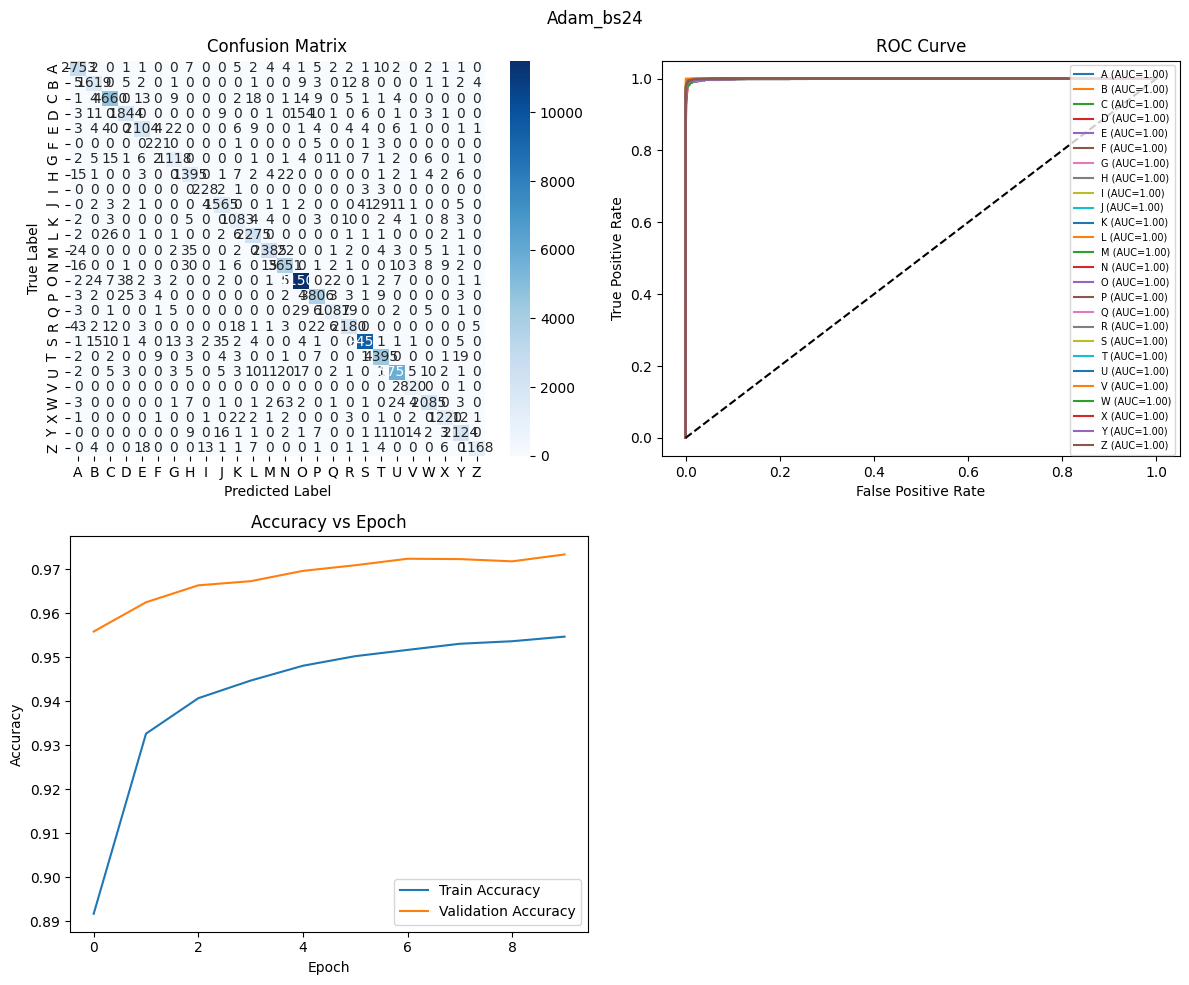


Training with Adam | Batch Size: 32
Epoch 1/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.8888 - loss: 0.3891 - val_accuracy: 0.9536 - val_loss: 0.1649
Epoch 2/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9329 - loss: 0.2313 - val_accuracy: 0.9607 - val_loss: 0.1369
Epoch 3/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9410 - loss: 0.2023 - val_accuracy: 0.9660 - val_loss: 0.1178
Epoch 4/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9454 - loss: 0.1857 - val_accuracy: 0.9685 - val_loss: 0.1091
Epoch 5/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9488 - loss: 0.1737 - val_accuracy: 0.9698 - val_loss: 0.1041
Epoch 6/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9505 - loss: 0.1678 - val_accuracy: 0.9713 - val_loss: 0.1003
Epoch 7/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9528 - loss: 0.1594 - val_accuracy: 0.9734 - val_loss: 0.0932
Epoch 8/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 

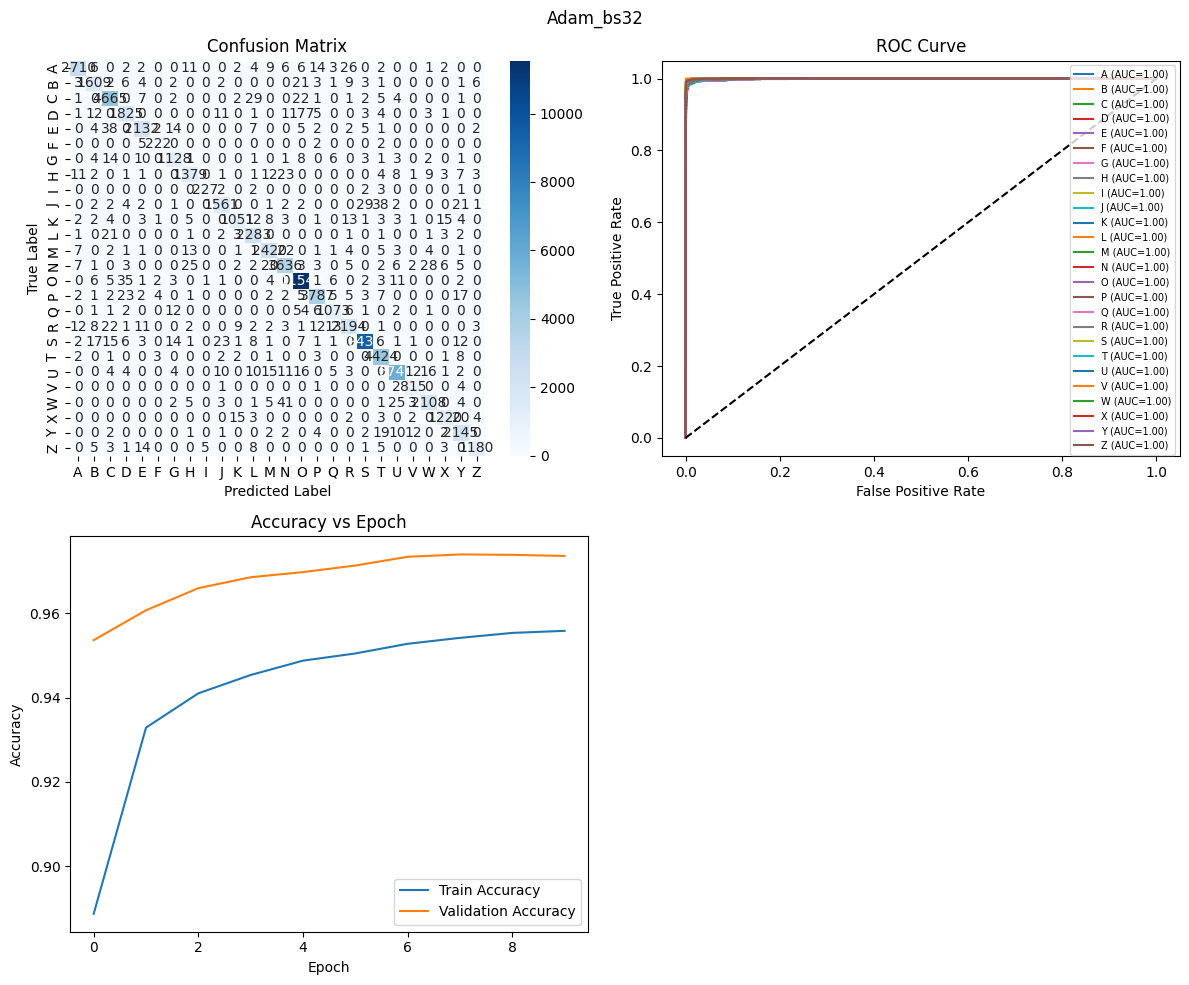


Training with SGD | Batch Size: 24
Epoch 1/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.5014 - loss: 1.8023 - val_accuracy: 0.7238 - val_loss: 1.0206
Epoch 2/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.7301 - loss: 0.9604 - val_accuracy: 0.8127 - val_loss: 0.6934
Epoch 3/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.7875 - loss: 0.7565 - val_accuracy: 0.8449 - val_loss: 0.5766
Epoch 4/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.8160 - loss: 0.6586 - val_accuracy: 0.8620 - val_loss: 0.5091
Epoch 5/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.8338 - loss: 0.5953 - val_accuracy: 0.8759 - val_loss: 0.4590
Epoch 6/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.8477 - loss: 0.5458 - val_accuracy: 0.8861 - val_loss: 0.4207
Epoch 7/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.8584 - loss: 0.5084 - val_accuracy: 0.8948 - val_loss: 0.3896
Epoch 8/10
12415/12415 ━━━━━━━━━━

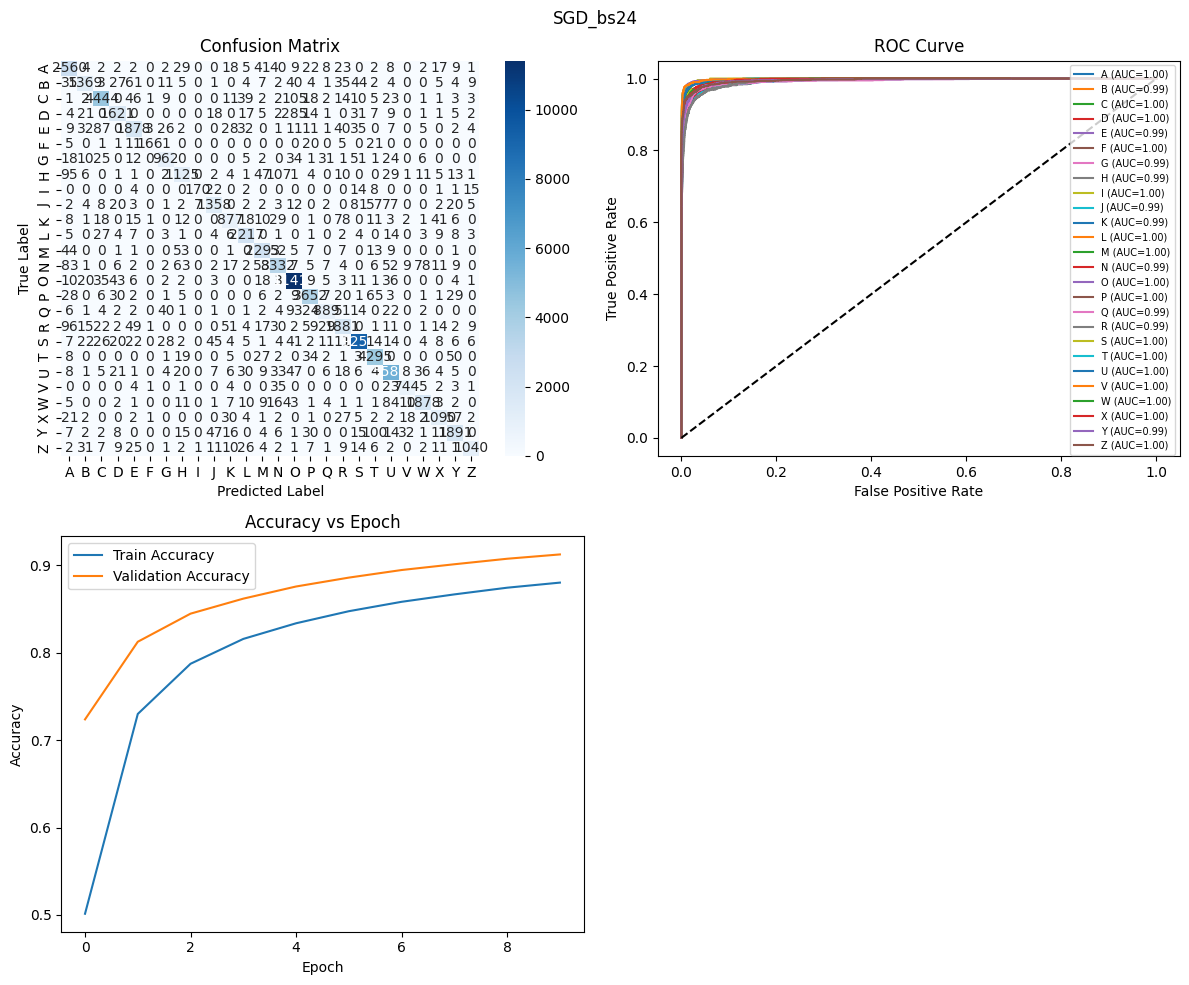


Training with SGD | Batch Size: 32
Epoch 1/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.4670 - loss: 1.9524 - val_accuracy: 0.6764 - val_loss: 1.1875
Epoch 2/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.6911 - loss: 1.0992 - val_accuracy: 0.7834 - val_loss: 0.8014
Epoch 3/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.7598 - loss: 0.8524 - val_accuracy: 0.8212 - val_loss: 0.6560
Epoch 4/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.7920 - loss: 0.7369 - val_accuracy: 0.8426 - val_loss: 0.5769
Epoch 5/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8130 - loss: 0.6653 - val_accuracy: 0.8568 - val_loss: 0.5233
Epoch 6/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8272 - loss: 0.6152 - val_accuracy: 0.8675 - val_loss: 0.4841
Epoch 7/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8397 - loss: 0.5745 - val_accuracy: 0.8764 - val_loss: 0.4513
Epoch 8/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 31s 3

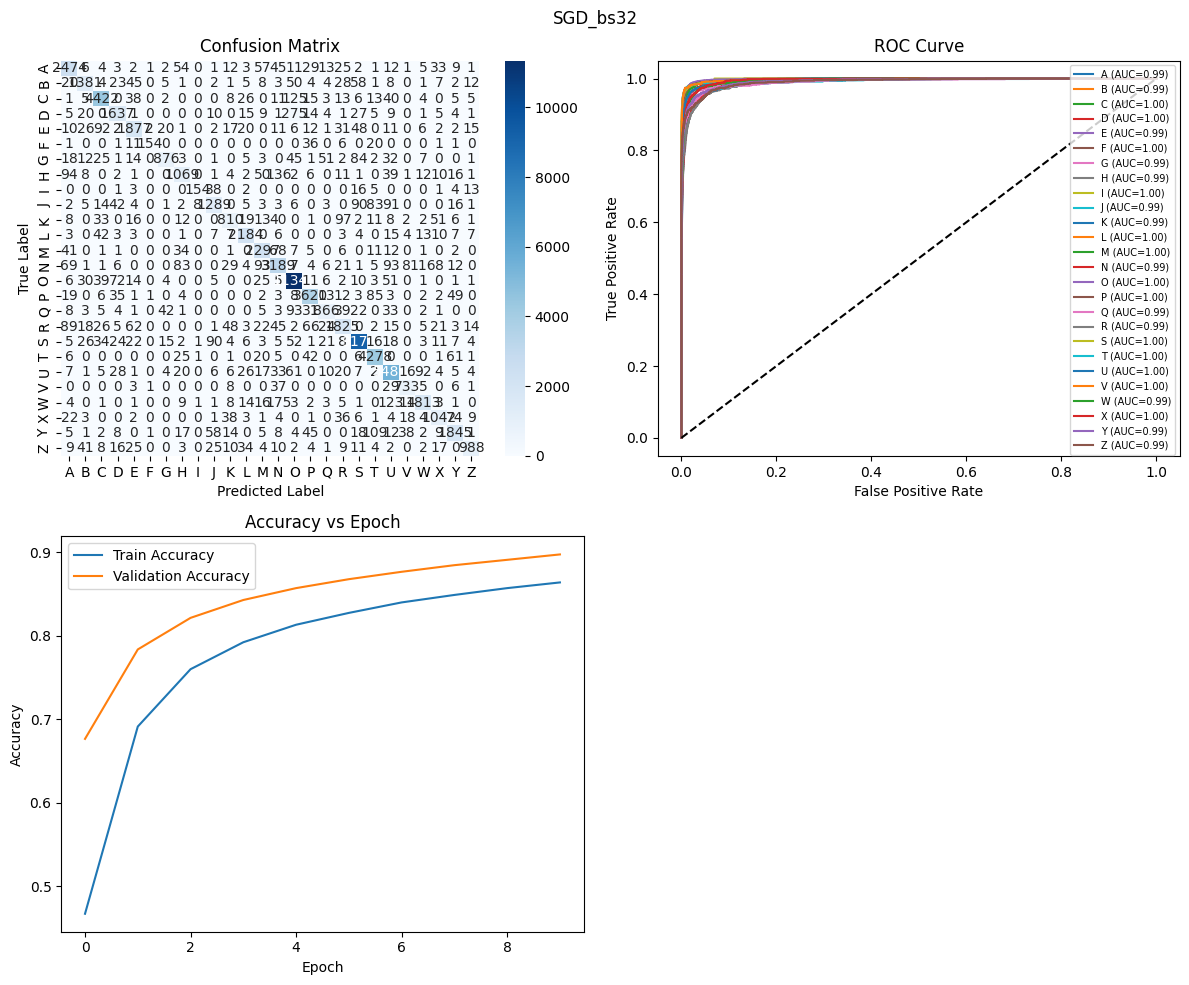


Training with RMSprop | Batch Size: 24
Epoch 1/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.8902 - loss: 0.4009 - val_accuracy: 0.9511 - val_loss: 0.1920
Epoch 2/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9268 - loss: 0.2901 - val_accuracy: 0.9567 - val_loss: 0.1770
Epoch 3/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9308 - loss: 0.2906 - val_accuracy: 0.9597 - val_loss: 0.1705
Epoch 4/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9322 - loss: 0.2990 - val_accuracy: 0.9595 - val_loss: 0.1956
Epoch 5/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9319 - loss: 0.3109 - val_accuracy: 0.9585 - val_loss: 0.2031
Epoch 6/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9326 - loss: 0.3213 - val_accuracy: 0.9607 - val_loss: 0.1856
Epoch 7/10
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9322 - loss: 0.3312 - val_accuracy: 0.9597 - val_loss: 0.1926
Epoch 8/10
12415/12415 ━━━━━━

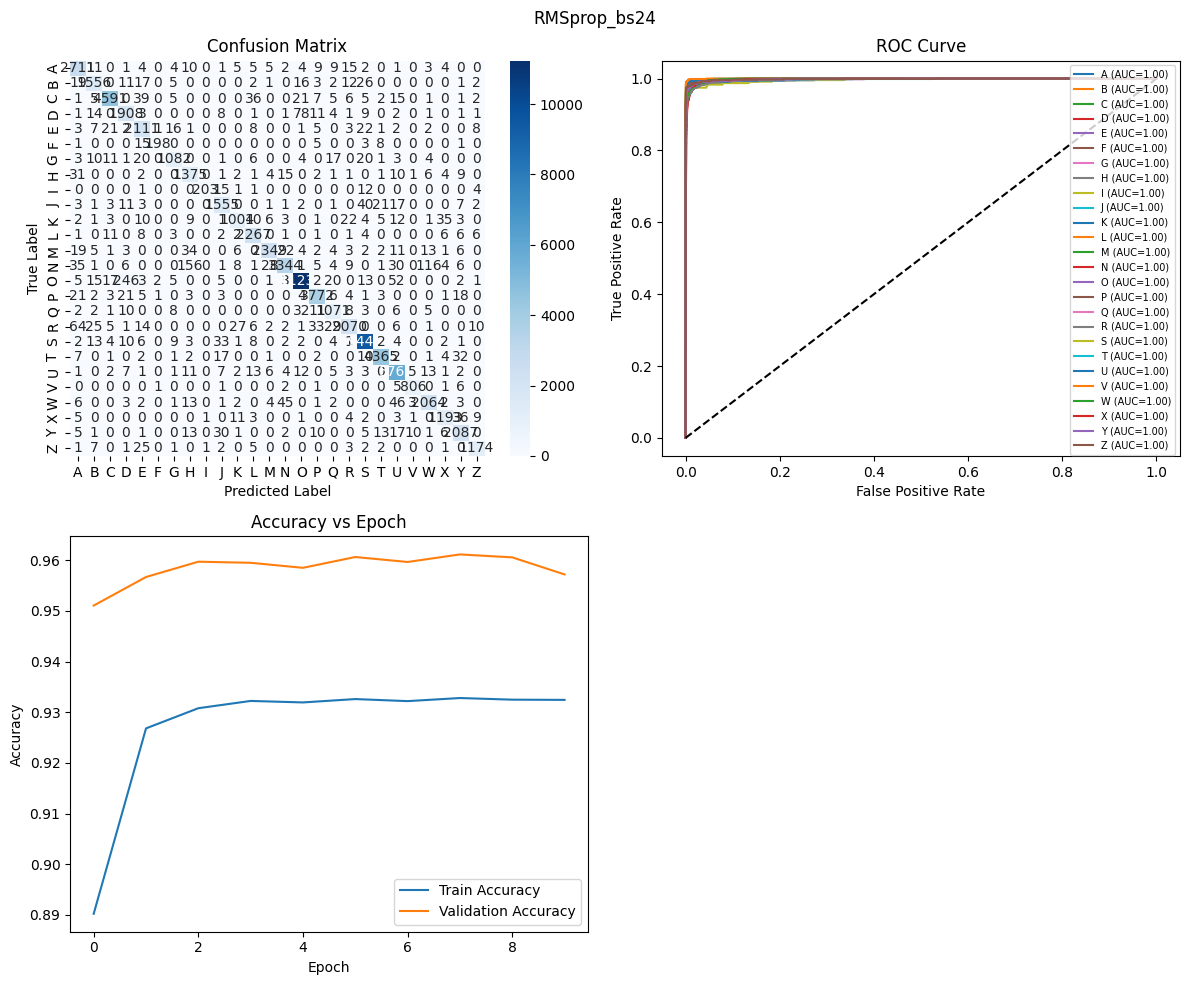


Training with RMSprop | Batch Size: 32
Epoch 1/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.8881 - loss: 0.3997 - val_accuracy: 0.9461 - val_loss: 0.1998
Epoch 2/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9287 - loss: 0.2668 - val_accuracy: 0.9567 - val_loss: 0.1671
Epoch 3/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.9348 - loss: 0.2546 - val_accuracy: 0.9620 - val_loss: 0.1527
Epoch 4/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9368 - loss: 0.2562 - val_accuracy: 0.9630 - val_loss: 0.1582
Epoch 5/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9382 - loss: 0.2600 - val_accuracy: 0.9634 - val_loss: 0.1662
Epoch 6/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9393 - loss: 0.2615 - val_accuracy: 0.9635 - val_loss: 0.1693
Epoch 7/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9390 - loss: 0.2673 - val_accuracy: 0.9641 - val_loss: 0.1678
Epoch 8/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 3

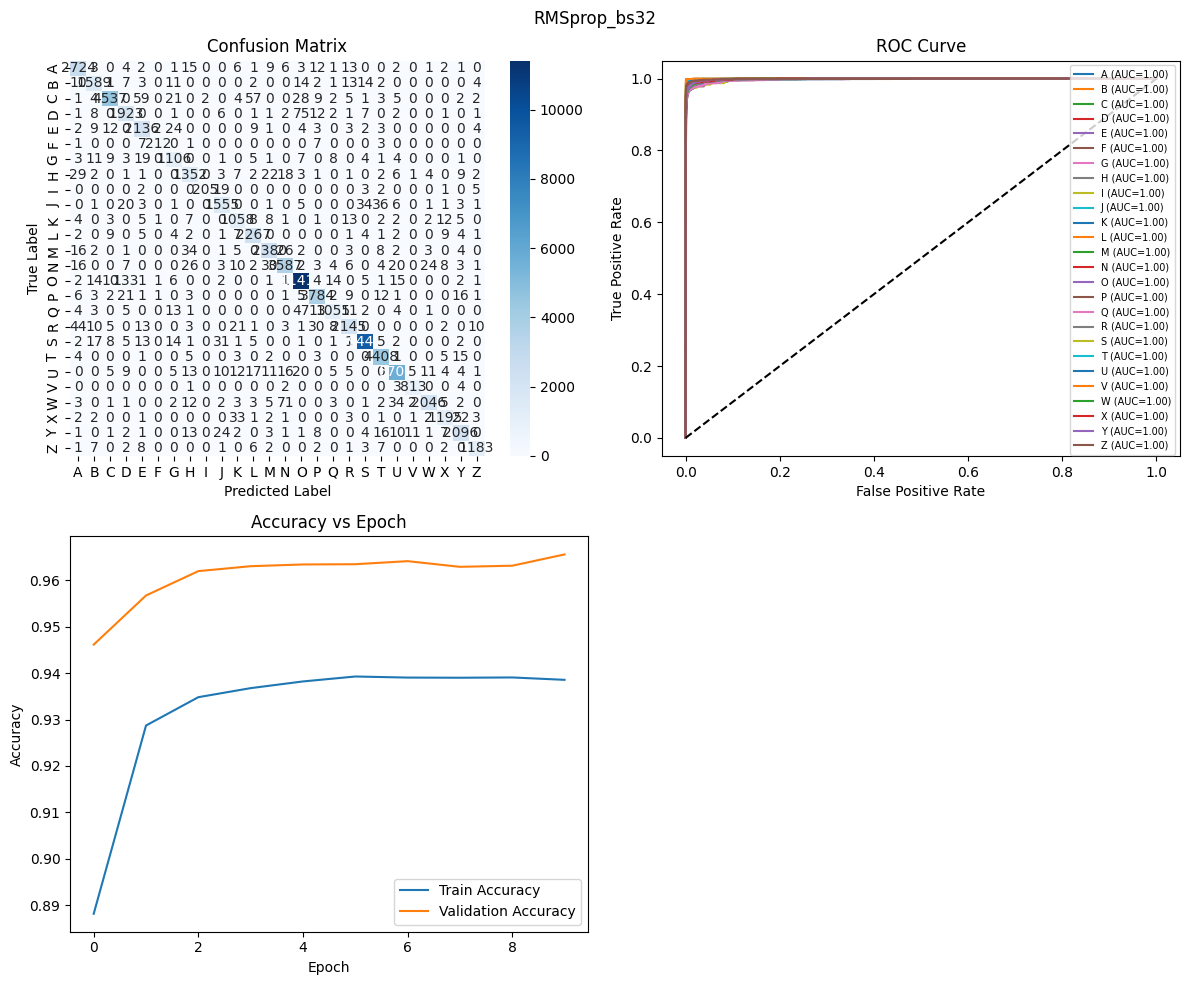

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

results = []
histories = {}

for opt_name, opt_class in optimizer_classes.items():
    for batch_size in batch_sizes:

        print(f"\nTraining with {opt_name} | Batch Size: {batch_size}")

        optimizer = opt_class(learning_rate=0.001)
        model = create_model(optimizer)

        history = model.fit(
            X_train, y_train,
            epochs=10,
            batch_size=batch_size,
            validation_data=(X_test, y_test),
            verbose=1
        )

        # 🔥 ADD THIS (you were missing it)
        y_proba = model.predict(X_test)
        y_pred = np.argmax(y_proba, axis=1)

        # Metrics
        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        f1 = f1_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        precision = precision_score(y_test, y_pred, average='macro')

        model_name = f"{opt_name}_bs{batch_size}"

        results.append({
            "Optimizer": opt_name,
            "Batch Size": batch_size,
            "Test Accuracy": acc,
            "Test Loss": loss,
            "F1": f1,
            "Recall": recall,
            "Precision": precision
        })

        histories[model_name] = history

        # Visualization
        plot_metrics(
            y_test,
            y_pred,
            y_proba,
            history,
            class_names,
            title=model_name
        )

In [ ]:
best_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
best_model = create_model(best_optimizer)

best_model.fit(X_train, y_train, epochs=10, batch_size=24, verbose=0)


In [ ]:
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


2328/2328 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


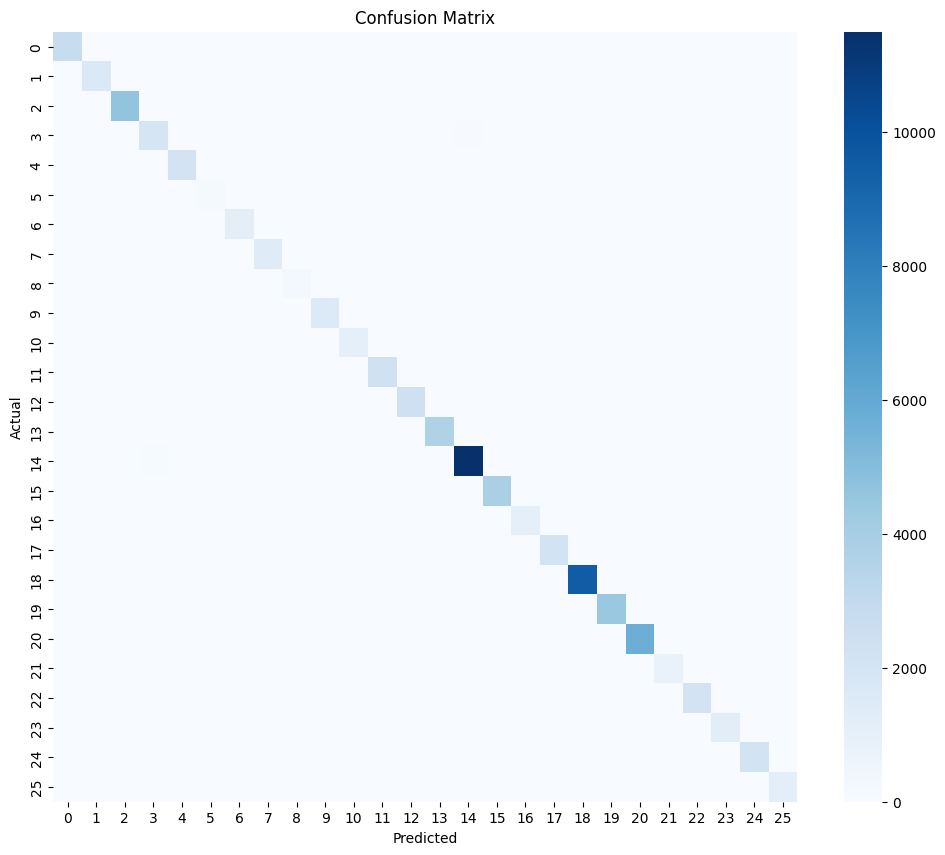

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_true, y_pred_classes))


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2806
           1       0.97      0.98      0.97      1673
           2       0.99      0.98      0.98      4742
           3       0.94      0.95      0.95      2044
           4       0.98      0.96      0.97      2214
           5       0.97      0.92      0.94       231
           6       0.95      0.97      0.96      1183
           7       0.95      0.97      0.96      1466
           8       0.93      0.97      0.95       237
           9       0.98      0.96      0.97      1668
          10       0.93      0.98      0.95      1132
          11       0.98      0.98      0.98      2319
          12       0.99      0.97      0.98      2487
          13       0.98      0.98      0.98      3756
          14       0.99      0.99      0.99     11629
          15       0.98      0.99      0.98      3868
          16       0.95      0.97      0.96      1159
          17       0.98    

In [1]:
# @title
import pandas as pd

# Total samples
TOTAL = 74490

# Input from your report
data = [
[0,0.97,0.98,0.98,2806],
[1,0.97,0.98,0.97,1673],
[2,0.99,0.98,0.98,4742],
[3,0.94,0.95,0.95,2044],
[4,0.98,0.96,0.97,2214],
[5,0.97,0.92,0.94,231],
[6,0.95,0.97,0.96,1183],
[7,0.95,0.97,0.96,1466],
[8,0.93,0.97,0.95,237],
[9,0.98,0.96,0.97,1668],
[10,0.93,0.98,0.95,1132],
[11,0.98,0.98,0.98,2319],
[12,0.99,0.97,0.98,2487],
[13,0.98,0.98,0.98,3756],
[14,0.99,0.99,0.99,11629],
[15,0.98,0.99,0.98,3868],
[16,0.95,0.97,0.96,1159],
[17,0.98,0.95,0.97,2296],
[18,0.99,1.00,0.99,9556],
[19,0.99,0.99,0.99,4447],
[20,0.99,0.98,0.99,5860],
[21,0.97,1.00,0.98,823],
[22,0.98,0.97,0.98,2198],
[23,0.98,0.97,0.98,1269],
[24,0.96,0.99,0.97,2202],
[25,0.98,0.97,0.98,1225]
]

rows = []

for cls, precision, recall, f1, support in data:
    TP = recall * support
    FN = support - TP
    FP = TP * (1/precision - 1)
    TN = TOTAL - (TP + FP + FN)

    specificity = TN / (TN + FP)
    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)
    error_rate = (FP + FN) / TOTAL

    rows.append([
        cls, precision, recall, f1, support,
        TP, TN, FP, FN,
        specificity, fpr, fnr, error_rate
    ])

df_results = pd.DataFrame(rows, columns=[
    "Class","Precision","Recall","F1","Support",
    "TP","TN","FP","FN",
    "Specificity","FPR","FNR","Error Rate"
])



In [ ]:
df_results

,Class,Precision,Recall,F1,Support,TP,TN,FP,FN,Specificity,FPR,FNR,Error Rate
0,0,0.97,0.98,0.98,2806,2749.88,71598.952165,85.047835,56.12,0.998814,0.001186,0.02,0.001895
1,1,0.97,0.98,0.97,1673,1639.54,72766.292577,50.707423,33.46,0.999304,0.000696,0.02,0.001130
2,2,0.99,0.98,0.98,4742,4647.16,69701.058990,46.941010,94.84,0.999327,0.000673,0.02,0.001903
3,3,0.94,0.95,0.95,2044,1941.80,72322.055319,123.944681,102.20,0.998289,0.001711,0.05,0.003036
4,4,0.98,0.96,0.97,2214,2125.44,72232.623673,43.376327,88.56,0.999400,0.000600,0.04,0.001771
5,5,0.97,0.92,0.94,231,212.52,74252.427216,6.572784,18.48,0.999911,0.000089,0.08,0.000336
6,6,0.95,0.97,0.96,1183,1147.51,73246.604737,60.395263,35.49,0.999176,0.000824,0.03,0.001287
7,7,0.95,0.97,0.96,1466,1422.02,72949.156842,74.843158,43.98,0.998975,0.001025,0.03,0.001595
8,8,0.93,0.97,0.95,237,229.89,74235.696452,17.303548,7.11,0.999767,0.000233,0.03,0.000328
9,9,0.98,0.96,0.97,1668,1601.28,72789.320816,32.679184,66.72,0.999551,0.000449,0.04,0.001334


📊 Overview

The model was evaluated on a multi-class classification task involving 26 classes (A–Z) using standard performance metrics including Precision, Recall, F1-score, Specificity, False Positive Rate (FPR), False Negative Rate (FNR), and Error Rate. A One-vs-Rest approach was used to derive extended metrics such as TP, TN, FP, and FN.

🏆 Overall Performance

Accuracy: ~98%

Macro Average (Precision/Recall/F1): ~0.97

Weighted Average: ~0.98

The model demonstrates high accuracy and balanced performance across most classes.

🔍 Class-wise Performance Analysis
Most classes achieve:

Precision: 0.95 – 0.99

Recall: 0.95 – 1.00

F1-score: 0.95 – 0.99

High-performing classes:

Class 14, 18, 19, 20 → near-perfect scores (≈0.99)

Class 18 and 21 show Recall = 1.00, meaning no missed predictions

Slightly weaker classes:

Class 5 → Recall = 0.92 (higher missed detections)

Class 3 and 17 → relatively higher FNR (~0.05)

📈 Error Analysis

False Positive Rate (FPR):
Extremely low (~ 0.0003 – 0.0018)
Indicates very few incorrect positive predictions

False Negative Rate (FNR):
Generally low (0.01 – 0.05)
Some classes show slightly higher miss rates

Error Rate:
Very low overall (~0.0003 – 0.0031)

🧠 Specificity Analysis

Specificity ≈ 0.998 – 0.999
Indicates excellent ability to correctly identify negative classes
Model rarely confuses one class with others
⚖️ Observations
Precision, Recall, and F1-score are closely aligned → balanced model
High specificity + low FPR → robust classification
Minor variation in FNR suggests some classes are slightly harder to detect
No significant class bias observed
📌 Conclusion

The model achieves high classification performance (~98% accuracy) with strong generalization across all 26 classes. It maintains excellent specificity and low error rates, indicating reliable predictions. While a few classes show slightly higher false negative rates, overall performance remains consistent and robust. The model is well-suited for real-world multi-class classification tasks.